# PERMASALAHAN
Selama ini, pembelajaran pemrograman Python masih menggunakan pendekatan yang seragam untuk semua orang. Padahal, setiap individu memiliki gaya belajar, kecepatan, dan tingkat pemahaman yang berbeda-beda. Akibatnya, banyak pemula yang ingin belajar Python mengalami kesulitan dalam memahami materi dan mengikuti proses pembelajaran.


# SOLUSI
Kami mengembangkan Sistem Rekomendasi Belajar Python dengan
Quiz Adaptif Berbasis Gaya Belajar. Sistem ini memanfaatkan kecerdasan
buatan untuk menciptakan suasana belajar yang lebih hidup dan
personal.tahapan nya adalah

1.Pre-Test Awal Pengetahuan Dasar Python

tujuan nya Menentukan titik awal kemampuan teknis user.User mengerjakan soal pilihan ganda tentang dasar python.Skor nya di sini menentukan materi apa yang harus diberikan

2.Pre-Test Gaya Belajar

Tujuan nya Menentukan profil psikologis belajar user.disini user mengisi kuesioner gaya belajar.Skor di sini menentukan  Bagaimana materi tersebut disajikan.

3.Pemberian Materi Berdasarkan Gaya Belajar

Tujuan nya untuk memberikan materi dasar python ke user berdasarkan hasil dari dua tahap sebelumnya, yaitu tingkat kemampuan user dan gaya belajar yang dimiliki, sehingga proses belajar user menjadi lebih efektif dan mudah dipahami.

4.Pre-Test Akhir Pengetahuan Dasar Python

Tujuan nya Mengukur peningkatan pengetahuan.Ujian akhir untuk melihat apakah user sudah paham setelah diberikan materi yang dipersonalisasi berdasarkan gaya belajar mereka.


## PERTANYAAN YANG INGIN DIANALISIS 1
Berdasarkan dataset hasil kuesioner dari keempat metode VARK, metode mana yang paling sering dipilih atau paling dominan oleh user?

## PERTANYAAN YANG INGIN DIANALISIS 2
Apakah seseorang punya lebih dari satu gaya belajar dominan?


## Import Semua Packages/Library yang Digunakan

In [294]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Data Wrangling

### Gathering Data

In [295]:
# Membaca dataset nya
url = "https://raw.githubusercontent.com/Dziarur/Capastone-Project/refs/heads/main/Dataset/Kuesioner%20Survei%20Gaya%20Belajar%20%26%20Personalisasi%20Pembelajaran%20Python%20%E2%80%93%20Capstone%20Project%20CC26-PSU140%20(Responses)%20-%20Form%20Responses%201.csv"
df = pd.read_csv(url)

In [296]:
# Menampilkan jumlah data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 26 columns):
 #   Column                                                                                                                       Non-Null Count  Dtype 
---  ------                                                                                                                       --------------  ----- 
 0   Timestamp                                                                                                                    131 non-null    object
 1   Email Address                                                                                                                131 non-null    object
 2   Nama                                                                                                                         131 non-null    object
 3   Umur                                                                                                                         

In [297]:
# Menampilkan 5 data teratas
df.head()

,Timestamp,Email Address,Nama,Umur,Asal Universitas,Jurusan,Saya merasa lebih mudah memahami logika pemrograman jika dijelaskan melalui diagram alur (flowchart),Saya lebih suka menonton video tutorial koding daripada mendengarkan penjelasan suara saja.,Penggunaan warna yang berbeda pada kode (seperti di VS Code) sangat membantu saya mengenali struktur program.,Saya sering membayangkan bagaimana alur data mengalir dalam program seperti sebuah peta di pikiran saya,...,Saya lebih suka membaca dokumentasi resmi atau buku teks Python untuk mendalami suatu materi.,Saya merasa harus menulis catatan atau rangkuman teks sendiri agar benar-benar memahami cara kerja sebuah fungsi.,Saya sangat menyukai penjelasan materi yang disajikan dalam bentuk daftar poin (bullet points) atau daftar langkah-langkah.,"Saat mencari solusi di internet, saya lebih memilih membaca artikel blog atau StackOverflow daripada menonton video.",Membaca komentar di dalam kode sangat membantu saya memahami tujuan dari baris kode tersebut.,Saya merasa bosan jika harus membaca teori terlalu lama tanpa mencoba langsung mengetik kodenya di komputer.,"Saya lebih cepat paham melalui metode trial and error (mencoba, salah, lalu memperbaiki sendiri).",Mengikuti tutorial live coding di mana saya mengetik bersamaan dengan instruktur adalah cara belajar favorit saya.,Saya lebih mudah memahami konsep Python jika saya mengaplikasikannya langsung ke dalam proyek nyata.,Saya merasa lebih percaya diri dengan kemampuan saya setelah berhasil memecahkan masalah koding secara mandiri.
0,4/17/2026 20:46:16,dziarurr@gmail.com,Dziarur,15 - 19 Tahun,UNNES,Statistika,5,4,5,4,...,2,2,5,3,3,5,5,3,4,5
1,4/17/2026 20:57:43,budi.juarto@gmail.com,a,> 25 Tahun,a,a,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
2,4/17/2026 20:59:29,hkmfile@gmail.com,Ulum,20 - 24 Tahun,Trilogi,sistem informasi,3,4,5,1,...,5,4,5,3,5,3,1,2,4,4
3,4/17/2026 21:00:12,muhageng61@gmail.com,Muhammad Ageng Ramadhan,20 - 24 Tahun,Universitas Indraprasta,Pendidikan Bahasa Inggris,4,5,5,4,...,3,5,4,4,4,5,5,3,5,5
4,4/17/2026 21:01:59,anakja2008@gmail.com,Naufal Fakhrizal Rafli,15 - 19 Tahun,Universitas Negeri Semarang,Statistika terapan dan Komputasi,4,4,4,4,...,3,3,5,2,4,5,5,3,3,4


### Assessing Data

In [298]:
# menilai tipe data nya
df.describe()

,Saya merasa lebih mudah memahami logika pemrograman jika dijelaskan melalui diagram alur (flowchart),Saya lebih suka menonton video tutorial koding daripada mendengarkan penjelasan suara saja.,Penggunaan warna yang berbeda pada kode (seperti di VS Code) sangat membantu saya mengenali struktur program.,Saya sering membayangkan bagaimana alur data mengalir dalam program seperti sebuah peta di pikiran saya,Saya lebih mudah mengingat perintah Python jika saya pernah melihatnya dalam bentuk infografis atau skema.,Saya merasa lebih cepat paham jika instruktur menjelaskan materi Python secara lisan di depan kelas/webinar.,Mendengarkan diskusi atau tanya jawab antar teman tentang suatu error membantu saya menemukan solusi.,Saya sering mengulang-ulang penjelasan guru di dalam hati atau dengan suara pelan untuk memahami konsep yang sulit.,Saya lebih suka mengikuti kursus yang menyediakan banyak sesi live session atau podcast teknis.,Instruksi yang diberikan melalui suara lebih mudah saya ikuti daripada instruksi yang hanya tertulis di layar.,Saya lebih suka membaca dokumentasi resmi atau buku teks Python untuk mendalami suatu materi.,Saya merasa harus menulis catatan atau rangkuman teks sendiri agar benar-benar memahami cara kerja sebuah fungsi.,Saya sangat menyukai penjelasan materi yang disajikan dalam bentuk daftar poin (bullet points) atau daftar langkah-langkah.,"Saat mencari solusi di internet, saya lebih memilih membaca artikel blog atau StackOverflow daripada menonton video.",Membaca komentar di dalam kode sangat membantu saya memahami tujuan dari baris kode tersebut.,Saya merasa bosan jika harus membaca teori terlalu lama tanpa mencoba langsung mengetik kodenya di komputer.,"Saya lebih cepat paham melalui metode trial and error (mencoba, salah, lalu memperbaiki sendiri).",Mengikuti tutorial live coding di mana saya mengetik bersamaan dengan instruktur adalah cara belajar favorit saya.,Saya lebih mudah memahami konsep Python jika saya mengaplikasikannya langsung ke dalam proyek nyata.,Saya merasa lebih percaya diri dengan kemampuan saya setelah berhasil memecahkan masalah koding secara mandiri.
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.00000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,3.938931,4.167939,3.908397,3.893130,3.770992,3.679389,4.167939,3.671756,3.80916,3.671756,3.488550,3.916031,3.893130,3.618321,3.893130,4.000000,4.229008,3.755725,4.007634,4.190840
std,0.990382,1.060861,1.112519,1.118047,1.199775,1.076084,1.089479,1.146518,1.19044,1.255405,1.230175,1.246769,1.104201,1.261611,1.124906,1.066987,1.106379,1.130634,1.091902,1.067812
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.00000,3.000000,2.000000,3.000000,3.000000,3.000000,3.500000,4.000000,4.000000,3.000000,3.000000,4.000000
50%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000
75%,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,5.000000,5.000000,5.00000,5.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [299]:

# Mengetahui tipe data masing-masing kolom
df.info()
# periksa apakah ada data value nya ada yang kosong
# periksa apakah ada data yang duplikat

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 26 columns):
 #   Column                                                                                                                       Non-Null Count  Dtype 
---  ------                                                                                                                       --------------  ----- 
 0   Timestamp                                                                                                                    131 non-null    object
 1   Email Address                                                                                                                131 non-null    object
 2   Nama                                                                                                                         131 non-null    object
 3   Umur                                                                                                                         

### Cleaning Data

In [300]:
# hapus kolom yang tidak kepakai kolom profile responden
kolom_dihapus = [
    'Timestamp', 'Email Address', 'Nama',
    'Umur', 'Asal Universitas', 'Jurusan'
]
df_cleaned = df.drop(columns=kolom_dihapus, errors='ignore')

# Menghapus index 1 pada dataset
df_cleaned = df_cleaned.drop(df_cleaned.index[1]).reset_index(drop=True)

print("\n=== Preview Dataset Setelah Cleaning ===")
display(df_cleaned.head(10))






=== Preview Dataset Setelah Cleaning ===


,Saya merasa lebih mudah memahami logika pemrograman jika dijelaskan melalui diagram alur (flowchart),Saya lebih suka menonton video tutorial koding daripada mendengarkan penjelasan suara saja.,Penggunaan warna yang berbeda pada kode (seperti di VS Code) sangat membantu saya mengenali struktur program.,Saya sering membayangkan bagaimana alur data mengalir dalam program seperti sebuah peta di pikiran saya,Saya lebih mudah mengingat perintah Python jika saya pernah melihatnya dalam bentuk infografis atau skema.,Saya merasa lebih cepat paham jika instruktur menjelaskan materi Python secara lisan di depan kelas/webinar.,Mendengarkan diskusi atau tanya jawab antar teman tentang suatu error membantu saya menemukan solusi.,Saya sering mengulang-ulang penjelasan guru di dalam hati atau dengan suara pelan untuk memahami konsep yang sulit.,Saya lebih suka mengikuti kursus yang menyediakan banyak sesi live session atau podcast teknis.,Instruksi yang diberikan melalui suara lebih mudah saya ikuti daripada instruksi yang hanya tertulis di layar.,Saya lebih suka membaca dokumentasi resmi atau buku teks Python untuk mendalami suatu materi.,Saya merasa harus menulis catatan atau rangkuman teks sendiri agar benar-benar memahami cara kerja sebuah fungsi.,Saya sangat menyukai penjelasan materi yang disajikan dalam bentuk daftar poin (bullet points) atau daftar langkah-langkah.,"Saat mencari solusi di internet, saya lebih memilih membaca artikel blog atau StackOverflow daripada menonton video.",Membaca komentar di dalam kode sangat membantu saya memahami tujuan dari baris kode tersebut.,Saya merasa bosan jika harus membaca teori terlalu lama tanpa mencoba langsung mengetik kodenya di komputer.,"Saya lebih cepat paham melalui metode trial and error (mencoba, salah, lalu memperbaiki sendiri).",Mengikuti tutorial live coding di mana saya mengetik bersamaan dengan instruktur adalah cara belajar favorit saya.,Saya lebih mudah memahami konsep Python jika saya mengaplikasikannya langsung ke dalam proyek nyata.,Saya merasa lebih percaya diri dengan kemampuan saya setelah berhasil memecahkan masalah koding secara mandiri.
0,5,4,5,4,4,3,4,3,3,4,2,2,5,3,3,5,5,3,4,5
1,3,4,5,1,2,4,5,2,3,1,5,4,5,3,5,3,1,2,4,4
2,4,5,5,4,5,5,5,5,5,5,3,5,4,4,4,5,5,3,5,5
3,4,4,4,4,3,3,4,4,3,3,3,3,5,2,4,5,5,3,3,4
4,4,5,1,1,1,3,3,1,3,1,1,1,5,3,5,5,4,4,5,5
5,5,5,4,5,3,3,4,2,3,2,5,3,3,5,4,5,5,4,5,5
6,2,5,4,4,2,3,4,2,4,4,2,1,4,2,2,5,5,4,5,5
7,5,4,5,5,3,3,5,1,1,1,1,4,5,3,5,4,5,1,3,5
8,4,4,5,5,3,3,5,4,3,3,2,4,4,2,5,3,5,4,5,5
9,5,5,4,5,3,3,4,4,5,3,3,1,4,3,2,4,5,3,5,5


In [301]:
# Membuat daftar nama kolom baru (V1-V5, A1-A5, R1-R5, K1-K5)
new_col_names = [
    'V1', 'V2', 'V3', 'V4', 'V5',  # Visual
    'A1', 'A2', 'A3', 'A4', 'A5',  # Auditory (Verbal)
    'R1', 'R2', 'R3', 'R4', 'R5',  # Reading/Writing
    'K1', 'K2', 'K3', 'K4', 'K5'   # Kinesthetic (Active)
]

# Mengganti nama kolom (karena tersisa pas 20 kolom, kita bisa langsung mapping semuanya)
rename_mapping = dict(zip(df_cleaned.columns, new_col_names))
df_cleaned_new_columns = df_cleaned.rename(columns=rename_mapping)

df_cleaned_new_columns.to_csv('Data_Clean.csv', index=False)

## Feature Engineering

In [302]:
# pembentukan kolom baru sesuai metode gaya belajar
# Menghitung rata-rata untuk masing-masing gaya belajar

path = 'Data_Clean.csv'
df_final = pd.read_csv(path)

df_final['Score_Visual'] = df_final[['V1', 'V2', 'V3', 'V4', 'V5']].mean(axis=1)
df_final['Score_Auditory'] = df_final[['A1', 'A2', 'A3', 'A4', 'A5']].mean(axis=1)
df_final['Score_ReadWrite'] = df_final[['R1', 'R2', 'R3', 'R4', 'R5']].mean(axis=1)
df_final['Score_Kinesthetic'] = df_final[['K1', 'K2', 'K3', 'K4', 'K5']].mean(axis=1)

df_final['Dominant_Style'] = df_final[kolom_skor] \
    .idxmax(axis=1) \
    .str.replace('Score_', '')

display(df_final.head(10))


,V1,V2,V3,V4,V5,A1,A2,A3,A4,A5,...,K1,K2,K3,K4,K5,Score_Visual,Score_Auditory,Score_ReadWrite,Score_Kinesthetic,Dominant_Style
0,5,4,5,4,4,3,4,3,3,4,...,5,5,3,4,5,4.4,3.4,3.0,4.4,Visual
1,3,4,5,1,2,4,5,2,3,1,...,3,1,2,4,4,3.0,3.0,4.4,2.8,ReadWrite
2,4,5,5,4,5,5,5,5,5,5,...,5,5,3,5,5,4.6,5.0,4.0,4.6,Auditory
3,4,4,4,4,3,3,4,4,3,3,...,5,5,3,3,4,3.8,3.4,3.4,4.0,Kinesthetic
4,4,5,1,1,1,3,3,1,3,1,...,5,4,4,5,5,2.4,2.2,3.0,4.6,Kinesthetic
5,5,5,4,5,3,3,4,2,3,2,...,5,5,4,5,5,4.4,2.8,4.0,4.8,Kinesthetic
6,2,5,4,4,2,3,4,2,4,4,...,5,5,4,5,5,3.4,3.4,2.2,4.8,Kinesthetic
7,5,4,5,5,3,3,5,1,1,1,...,4,5,1,3,5,4.4,2.2,3.6,3.6,Visual
8,4,4,5,5,3,3,5,4,3,3,...,3,5,4,5,5,4.2,3.6,3.4,4.4,Kinesthetic
9,5,5,4,5,3,3,4,4,5,3,...,4,5,3,5,5,4.4,3.8,2.6,4.4,Visual


In [303]:
# Menyimpan Dataset gaya belajar
df_final.to_csv('Data_Final.csv', index=False)

## Exploratory Data Analysis (EDA)

### Explore ...

In [304]:
# Menentukan gaya belajar yang paling disukai oleh responden
# Menentukan Gaya Belajar Dominan (Target Label)
# Mengambil nama kolom yang memiliki skor tertinggi untuk setiap user
kolom_skor = ['Score_Visual', 'Score_Auditory', 'Score_ReadWrite', 'Score_Kinesthetic']

# idxmax() mencari kolom mana yang nilainya paling besar.
# .str.replace() digunakan agar outputnya rapi (misal dari "Score_Visual" menjadi "Visual" saja)
df_final['Dominant_Style'] = df_final[kolom_skor].idxmax(axis=1).str.replace('Score_', '')

# Menampilkan distribusi gaya belajar dari 131 responden
print("\n=== Distribusi Gaya Belajar Dominan ===")
print(df_final['Dominant_Style'].value_counts())



=== Distribusi Gaya Belajar Dominan ===
Dominant_Style
Visual         53
Auditory       30
Kinesthetic    30
ReadWrite      17
Name: count, dtype: int64


In [305]:
file_path = 'Data_Final.csv'
df = pd.read_csv(file_path)

score_cols = ['Score_Visual', 'Score_Auditory', 'Score_ReadWrite', 'Score_Kinesthetic']

# Mencari skor tertinggi dari masing-masing baris (user)
max_scores = df[score_cols].max(axis=1)

# Menghitung berapa banyak kolom skor yang nilainya sama dengan skor tertinggi tersebut
# Jika > 1, berarti dia Multimodal (seri di beberapa gaya belajar)
num_dominant_styles = df[score_cols].eq(max_scores, axis=0).sum(axis=1)

multimodal_count = (num_dominant_styles > 1).sum()
total_respondents = len(df)
persentase = (multimodal_count / total_respondents) * 100

print("=== Analisis Gaya Belajar Dominan Unimodal ===")
print(f"Total Responden: {total_respondents}")
print(f"Jumlah responden Multimodal (>1 gaya dominan): {multimodal_count} responden ({persentase:.2f}%)")

=== Analisis Gaya Belajar Dominan Unimodal ===
Total Responden: 130
Jumlah responden Multimodal (>1 gaya dominan): 62 responden (47.69%)


In [306]:
# korelasi antar skor metode belajar
# 1. Visual ↔ Auditory
# 2. Visual ↔ Read/Write
# 3. Visual ↔ Kinesthetic
# 4. Auditory ↔ Read/Write
# 5. Auditory ↔ Kinesthetic
# 6. Read/Write ↔ Kinesthetic

# Membaca Dataset
file_path = 'Data_Final.csv'
df = pd.read_csv(file_path)

# Mendefinisikan kolom skor gaya belajar VARK
score_cols = ['Score_Visual', 'Score_Auditory', 'Score_ReadWrite', 'Score_Kinesthetic']

# Menghitung matriks korelasi (Pearson Correlation)
correlation_matrix = df[score_cols].corr()

# Mendefinisikan pasangan yang ingin dicari nilainya
pairs = [
    ('Score_Visual', 'Score_Auditory'),
    ('Score_Visual', 'Score_ReadWrite'),
    ('Score_Visual', 'Score_Kinesthetic'),
    ('Score_Auditory', 'Score_ReadWrite'),
    ('Score_Auditory', 'Score_Kinesthetic'),
    ('Score_ReadWrite', 'Score_Kinesthetic')
]

print("=== Hasil Analisis Korelasi Antar Skor Gaya Belajar ===")
# Looping untuk mencetak hasil yang rapi
for col1, col2 in pairs:
    # Mengambil nilai korelasi dari matriks
    corr_val = correlation_matrix.loc[col1, col2]

    # Membersihkan nama kolom agar enak dibaca (menghapus kata "Score_")
    nama1 = col1.replace('Score_', '')
    nama2 = col2.replace('Score_', '')

    # Mencetak hasil dengan 4 angka di belakang koma
    print(f"{nama1} <-> {nama2} : {corr_val:.4f}")

print("\n" + "="*50 + "\n")



=== Hasil Analisis Korelasi Antar Skor Gaya Belajar ===
Visual <-> Auditory : 0.8001
Visual <-> ReadWrite : 0.7888
Visual <-> Kinesthetic : 0.8896
Auditory <-> ReadWrite : 0.8080
Auditory <-> Kinesthetic : 0.7904
ReadWrite <-> Kinesthetic : 0.7416




## Visualization & Explanatory Analysis

/tmp/ipykernel_17786/3763940345.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=distribusi.index, y=distribusi.values, palette='viridis')


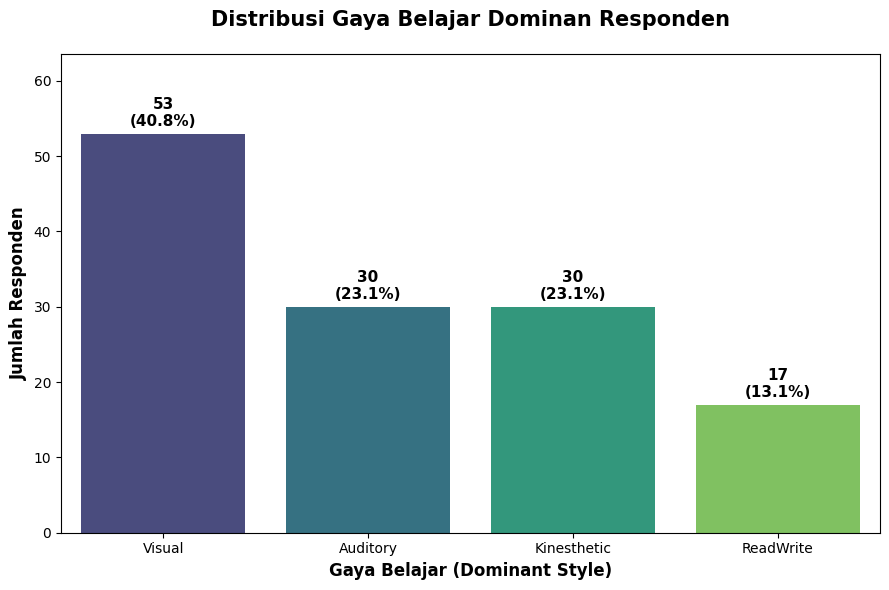

In [307]:
# visual pertanyaan yang ingin dianalisis 1
# Kalkulasi Data
df_final['Dominant_Style'] = df_final[kolom_skor].idxmax(axis=1).str.replace('Score_', '')
distribusi = df_final['Dominant_Style'].value_counts()

# Membuat Visualisasi: Bar Chart
plt.figure(figsize=(9, 6))

# Membuat batang menggunakan Seaborn
# palette='viridis' memberikan gradasi warna profesional yang sangat bagus untuk laporan sains data
ax = sns.barplot(x=distribusi.index, y=distribusi.values, palette='viridis')

# Menambahkan label angka & persentase tepat di atas setiap batang
total_responden = sum(distribusi.values)
for p in ax.patches:
    tinggi = p.get_height()
    persentase = f'{100 * tinggi / total_responden:.1f}%'
    # Menaruh teks di tengah batang (x) dan sedikit di atas batang (y)
    ax.text(p.get_x() + p.get_width() / 2., tinggi + 1,
            f'{int(tinggi)}\n({persentase})',
            ha="center", fontsize=11, fontweight='bold')

# Konfigurasi Judul dan Label Sumbu
plt.title('Distribusi Gaya Belajar Dominan Responden', fontsize=15, pad=20, weight='bold')
plt.xlabel('Gaya Belajar (Dominant Style)', fontsize=12, weight='bold')
plt.ylabel('Jumlah Responden', fontsize=12, weight='bold')

# Memberikan sedikit ruang kosong di atas batang agar teks tidak terpotong
plt.ylim(0, max(distribusi.values) * 1.2)
plt.tight_layout()

# Tampilkan Plot
plt.show()

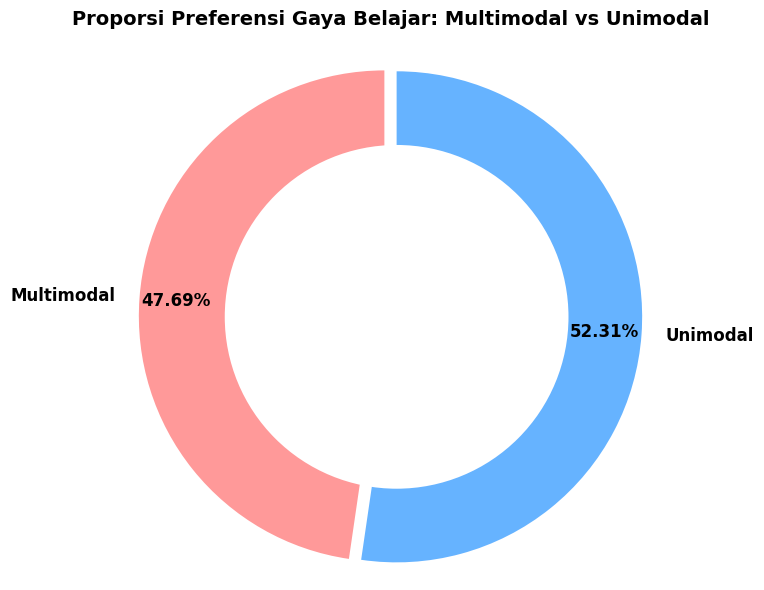

In [308]:
# visual pertanyaan yang ingin dianalisis 2
# Kalkulasi Data
max_scores = df[score_cols].max(axis=1)
num_dominant_styles = df[score_cols].eq(max_scores, axis=0).sum(axis=1)

multimodal_count = (num_dominant_styles > 1).sum()
total_respondents = len(df)
unimodal_count = total_respondents - multimodal_count

# Membuat Visualisasi: Donut Chart
labels = ['Multimodal', 'Unimodal']
sizes = [multimodal_count, unimodal_count]
colors = ['#ff9999', '#66b3ff']
explode = (0.05, 0)  # Efek memisahkan sedikit potongan Multimodal

plt.figure(figsize=(8, 6))

# Membuat Pie Chart dasar
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.2f%%', startangle=90, pctdistance=0.85,
        textprops={'fontsize': 12, 'weight': 'bold'})

# Menambahkan lingkaran putih di tengah agar menjadi Donut Chart
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Konfigurasi akhir visual
plt.title('Proporsi Preferensi Gaya Belajar: Multimodal vs Unimodal', fontsize=14, pad=20, weight='bold')
plt.axis('equal')  # Memastikan chart berbentuk lingkaran sempurna
plt.tight_layout()

# Tampilkan Plot
plt.show()



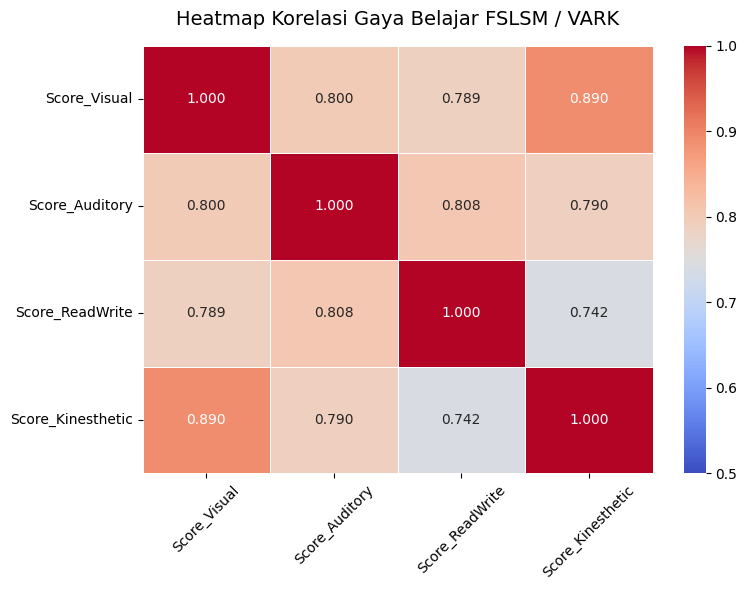

In [309]:
# ==========================================
# VISUALISASI HEATMAP KORELASI (Opsional)
# ==========================================
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix,
            annot=True,              # Menampilkan angka di dalam kotak
            cmap='coolwarm',         # Skala warna (merah=tinggi, biru=rendah)
            vmin=0.5, vmax=1,        # Batas nilai warna (karena rata-rata di atas 0.7)
            fmt=".3f",               # Format angka 3 desimal
            linewidths=0.5)

plt.title('Heatmap Korelasi Gaya Belajar FSLSM / VARK', pad=15, fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()

# Tampilkan plot
plt.show()

**Insight:**



## Conclution pertanyaan 1
Berdasarkan hasil analisis distribusi gaya belajar dominan, dapat disimpulkan bahwa mayoritas responden memiliki kecenderungan gaya belajar Visual, dengan jumlah 53 responden (40,8%). Hal ini menunjukkan bahwa sebagian besar mahasiswa lebih mudah memahami materi pembelajaran melalui media visual seperti diagram, video, atau ilustrasi.

Selanjutnya, gaya belajar Auditory dan Kinesthetic masing-masing memiliki jumlah yang sama, yaitu 30 responden (23,1%). Ini mengindikasikan bahwa cukup banyak mahasiswa yang juga mengandalkan penjelasan verbal maupun praktik langsung dalam proses belajar.

Sementara itu, gaya belajar Read/Write memiliki jumlah paling sedikit, yaitu 17 responden (13,1%). Hal ini menunjukkan bahwa metode pembelajaran berbasis teks seperti membaca dan menulis bukan merupakan preferensi utama bagi sebagian besar responden.

Secara keseluruhan, hasil ini mengindikasikan bahwa meskipun gaya belajar Visual mendominasi, terdapat variasi preferensi yang cukup signifikan di antara responden. Oleh karena itu, pendekatan pembelajaran yang efektif sebaiknya mengombinasikan berbagai metode, seperti visualisasi, penjelasan verbal, serta praktik langsung, untuk mengakomodasi kebutuhan belajar yang beragam.
## Conclution pertanyaan 2
Berdasarkan hasil analisis, mayoritas responden memiliki preferensi gaya belajar unimodal sebesar 52,31%, sementara 47,69% lainnya termasuk dalam kategori multimodal. Hal ini menunjukkan bahwa meskipun sebagian besar mahasiswa cenderung memiliki satu gaya belajar dominan, proporsi responden yang menggabungkan lebih dari satu gaya belajar juga sangat signifikan dan hampir seimbang.

Temuan ini mengindikasikan bahwa pendekatan pembelajaran yang hanya berfokus pada satu metode mungkin belum sepenuhnya optimal. Sebaliknya, kombinasi berbagai metode pembelajaran seperti visual, auditori, membaca/menulis, dan praktik langsung berpotensi lebih efektif dalam mengakomodasi kebutuhan belajar mahasiswa yang beragam.

Selain itu, tingginya proporsi multimodal menunjukkan bahwa banyak mahasiswa tidak terpaku pada satu cara belajar saja, melainkan mampu beradaptasi dengan berbagai pendekatan. Oleh karena itu, strategi pembelajaran yang fleksibel dan variatif sangat direkomendasikan untuk meningkatkan pemahaman dan efektivitas proses belajar.

## Conclution Heatmap Korelasi
Berdasarkan hasil analisis korelasi antar gaya belajar, terlihat bahwa seluruh pasangan variabel memiliki korelasi positif yang cukup kuat (berkisar antara 0,742 hingga 0,890). Hal ini menunjukkan bahwa tidak ada hubungan yang saling bertolak belakang antar gaya belajar, melainkan cenderung saling melengkapi.

Korelasi tertinggi ditemukan antara Visual dan Kinesthetic (0,890), yang mengindikasikan bahwa responden yang memiliki kecenderungan belajar secara visual juga cenderung menyukai pembelajaran berbasis praktik. Selain itu, hubungan yang kuat juga terlihat antara Auditory dan Read/Write (0,808), menunjukkan bahwa gaya belajar berbasis pendengaran seringkali berkaitan dengan preferensi terhadap teks dan penjelasan tertulis.

Sementara itu, korelasi terendah terdapat pada hubungan antara Read/Write dan Kinesthetic (0,742), meskipun masih dalam kategori kuat. Hal ini menunjukkan bahwa meskipun hubungan keduanya tidak sekuat pasangan lainnya, tetap terdapat keterkaitan yang signifikan.

Secara keseluruhan, hasil ini mengindikasikan bahwa responden cenderung tidak hanya mengandalkan satu gaya belajar saja, melainkan memiliki kecenderungan untuk mengombinasikan berbagai pendekatan dalam proses belajar. Temuan ini memperkuat hasil sebelumnya bahwa gaya belajar multimodal cukup dominan di antara responden.

